In [ ]:
#churn prdiction: customers are leaving the company
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

In [ ]:
df=pd.read_excel("Telco_customer_churn.xlsx")

EDA (EXPLORING THE DATA)

Text(0.5, 1.0, 'Distribution of Tenure Months vs no of customer')

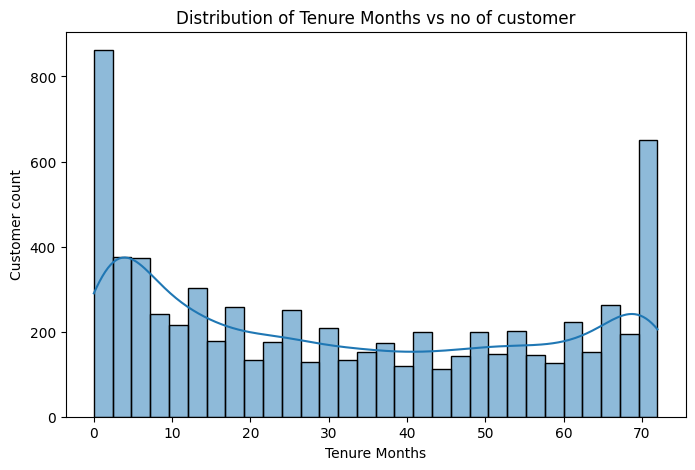

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Tenure Months'], bins=30, kde=True)

plt.xlabel('Tenure Months')

plt.ylabel('Customer count')

plt.title('Distribution of Tenure Months vs no of customer')

In [ ]:
plt.show()

In [ ]:
df.shape

(7043, 33)

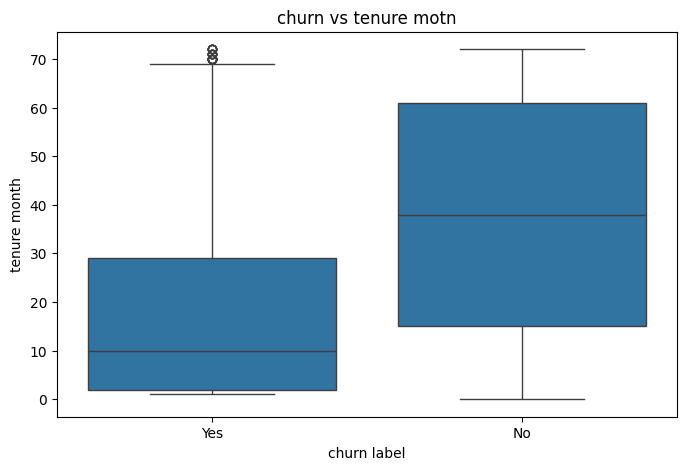

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn Label',y='Tenure Months', data=df)

plt.xlabel('churn label')

plt.ylabel('tenure month')

plt.title('churn vs tenure motn')

plt.show()

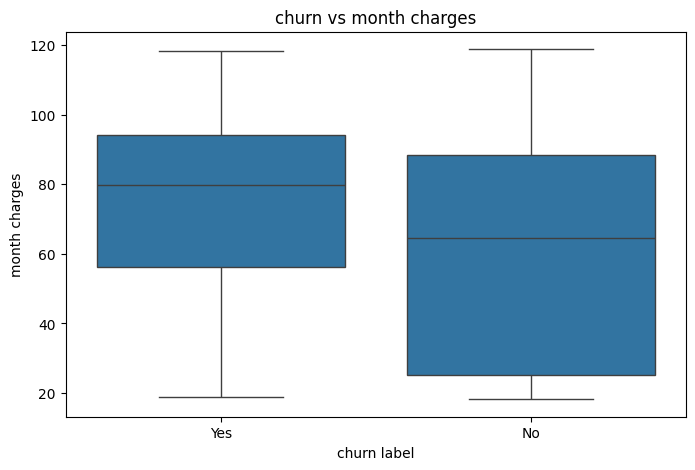

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn Label',y='Monthly Charges', data=df)

plt.xlabel('churn label')

plt.ylabel('month charges')

plt.title('churn vs month charges')

plt.show()

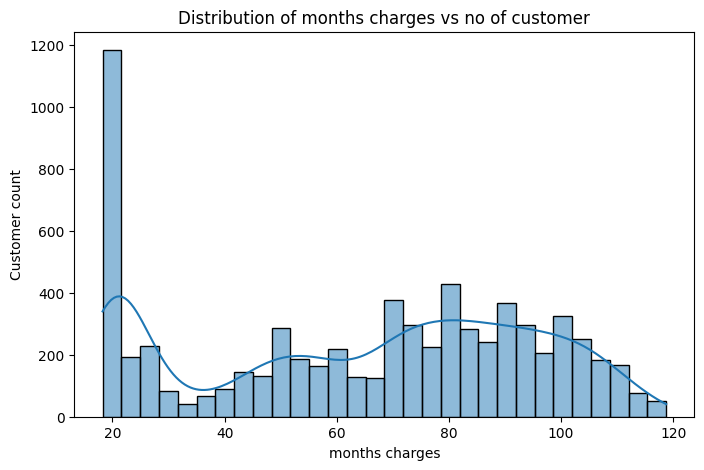

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Monthly Charges'], bins=30, kde=True)

plt.xlabel('months charges')

plt.ylabel('Customer count')

plt.title('Distribution of months charges vs no of customer')

plt.show()

In [ ]:
df['Monthly Charges'].quantile( [0.25,0.5,0.75])


,Monthly Charges
0.25,35.50
0.50,70.35
0.75,89.85


In [ ]:
df['Monthly Charges'].describe()


,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [ ]:

df[df['Churn Label']=='Yes'] ['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [ ]:
df[df['Churn Label']=='No'] ['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


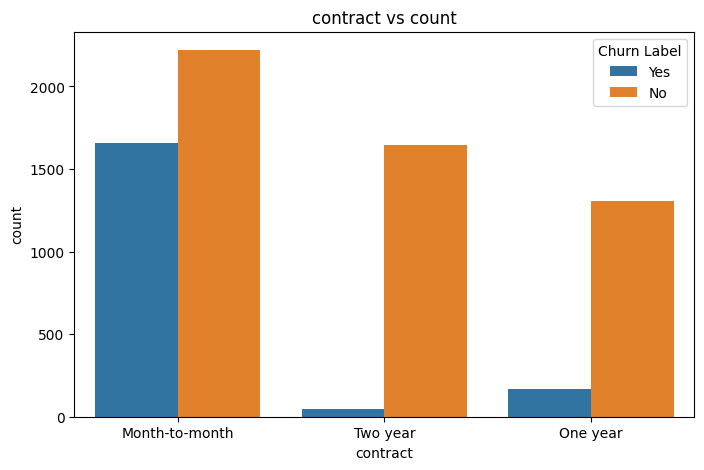

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='Contract',hue='Churn Label', data=df)

plt.xlabel('contract')

plt.ylabel('count')

plt.title('contract vs count')

plt.show()

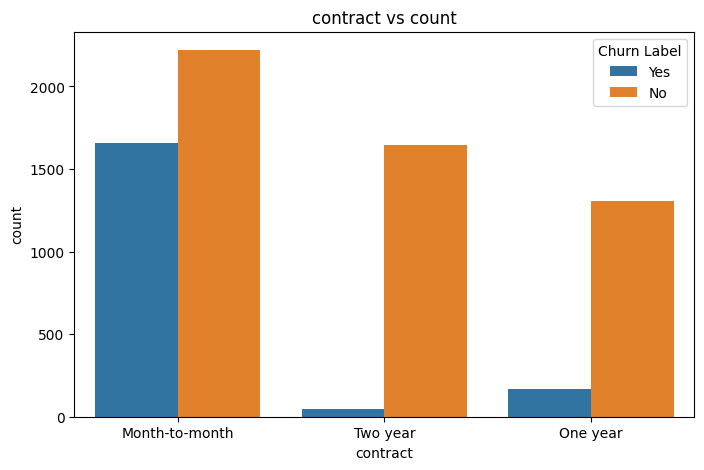

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='Contract',hue='Churn Label', data=df)

plt.xlabel('contract')

plt.ylabel('count')

plt.title('contract vs count')

plt.show()

In [ ]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [ ]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

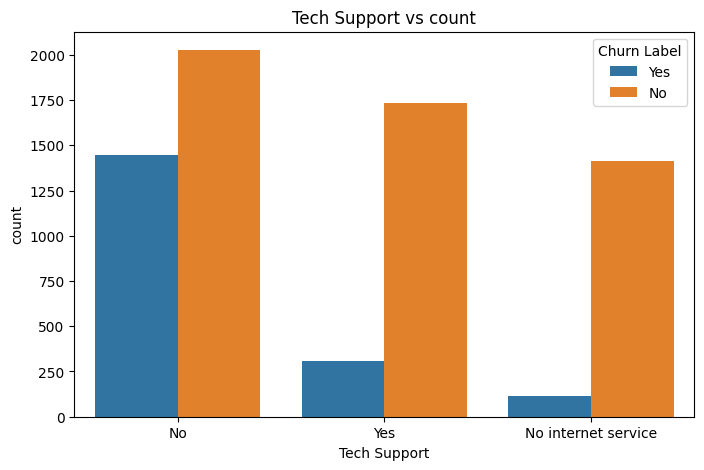

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='Tech Support',hue='Churn Label', data=df)

plt.xlabel('Tech Support')

plt.ylabel('count')

plt.title('Tech Support vs count')

plt.show()

#the people who are joining in tech support are leaving more if no support

In [ ]:
#groupby- when we want to partition our data into categories
#aggregate func-max, min, avg
avg_tenure = df.groupby("Churn Label")['Tenure Months'].mean()

In [ ]:
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
#correlation- x,y inc; x inc-y dec:used for numerical columns
cols = ['Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score','CLTV']
correlation_matrix = df[cols].corr()

In [ ]:
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


In [ ]:
#bivariate analysis
contract_churn = pd.crosstab(df['Contract'], df['Churn Label'])
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [ ]:
contract_churn = pd.crosstab(df['Contract'], df['Churn Label'],normalize='index')
contract_churn
#normalize-percentage of an column

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


**Data Cleaning**
-Encoding,
remove null values or duplicates,fill missing values
convert string to numerical value

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3
...,...
7038,1419.4
7039,1990.5
7040,7362.9
7041,346.45


In [ ]:
#convert strings to numeric
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [ ]:
df['Total Charges'].dtype

dtype('float64')

In [ ]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [ ]:
df[df['Total Charges'].isnull()]['Tenure Months']

,Tenure Months
2234,0
2438,0
2568,0
2667,0
2856,0
4331,0
4687,0
5104,0
5719,0
6772,0


In [ ]:
df[df['Total Charges'].isnull()]['Tenure Months'].shape

(11,)

In [ ]:
df['Total Charges'] =  df['Total Charges'].fillna(0)

In [ ]:
df['Total Charges'].isnull().sum()

np.int64(0)

drop cols:
cus id
country
state
lat
long
count
-----------------
churn label--direct yes or no, churn score , cltv--if life time is more that show the ans like he is not leaving the company(shows future revenue, future retention indirectly), churn reason--these are data leakage cols, so remove

In [ ]:
drop_columns = [
    'CustomerID',
    'Count',
    'City',
    'Country',
    'State',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Churn Label',
    'Churn Score',
    'CLTV',
    'Churn Reason'
]

data leakage:ans already given in dataset-model accidently get info about the ans

In [ ]:
columns_to_drop_existing = [col for col in drop_columns if col in df.columns]
if columns_to_drop_existing:
    df = df.drop(columns=columns_to_drop_existing)

In [ ]:
df.shape

(7043, 20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [ ]:
df_encoded = pd.get_dummies(df, drop_first = True)

In [ ]:
df_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False


In [ ]:
df_encoded.shape

(7043, 31)

In [ ]:
df_encoded
#final data

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,72,21.15,1419.40,0,False,False,False,False,True,False,...,True,False,True,False,False,True,True,False,False,False
7039,24,84.80,1990.50,0,True,False,True,True,True,False,...,False,True,False,True,True,False,True,False,False,True
7040,72,103.20,7362.90,0,False,False,True,True,True,False,...,False,True,False,True,True,False,True,True,False,False
7041,11,29.60,346.45,0,False,False,True,True,False,True,...,False,False,False,False,False,False,True,False,True,False


In [ ]:
X = df_encoded.drop('Churn Value', axis = 1)
Y = df_encoded['Churn Value']
#axis = 0 row, 1 means col

In [ ]:
X.shape
Y.shape

(7043,)

In [ ]:
print(X)

      Tenure Months  Monthly Charges  Total Charges  Gender_Male  \
0                 2            53.85         108.15         True   
1                 2            70.70         151.65        False   
2                 8            99.65         820.50        False   
3                28           104.80        3046.05        False   
4                49           103.70        5036.30         True   
...             ...              ...            ...          ...   
7038             72            21.15        1419.40        False   
7039             24            84.80        1990.50         True   
7040             72           103.20        7362.90        False   
7041             11            29.60         346.45        False   
7042             66           105.65        6844.50         True   

      Senior Citizen_Yes  Partner_Yes  Dependents_Yes  Phone Service_Yes  \
0                  False        False           False               True   
1                  False       

In [ ]:
print(Y)

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Value, Length: 7043, dtype: int64


**Machine learning implemetation**

In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [ ]:
X_train.shape

(5634, 30)

In [ ]:
X_test.shape

(1409, 30)

In [ ]:
Y_train.shape

(5634,)

In [ ]:
Y_test.shape

(1409,)

take accuracy to 85%+
decision tree - if else statements
take dataset
find the feature that fits pefectly for splitting
bsed on that condition split data
split dat
stop when no splitting features found


on what basis(feature) we need to split
entropy: measure impurity - sigma pi logpi



KNN -- depends on distance -- use scaling make every col val to (0 to 1), KMeans -- depends on the nearest neighbour



decision tree- learn all rules and logic efficiently and do the splitting

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)

In [ ]:
rf_model.fit(X_train,Y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

In [ ]:
y_pred

array([0, 0, 0, ..., 1, 0, 1])

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy = accuracy_score(Y_test, y_pred)
print(accuracy)

0.7856635911994322


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
cm = confusion_matrix(Y_test, y_pred)

In [ ]:
print(cm)

[[902 107]
 [195 205]]


In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(Y_test, y_pred))


              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1009
           1       0.66      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



**apprach 1** to handle class imbalance
random forest will find the imp feature automatically with a small formula

In [ ]:
rf_balanced = RandomForestClassifier(n_estimators = 100, class_weight = 'balanced', random_state=42)
rf_balanced.fit(X_train, Y_train)
y_pred_balanced = rf_balanced.predict(X_test)
accuracy_balanced = accuracy_score(Y_test, y_pred_balanced)
cm_balaned = confusion_matrix(Y_test, y_pred_balanced)
print(accuracy_balanced)
print(cm_balaned)
print(classification_report(Y_test, y_pred_balanced))
#


0.7920511000709723
[[907 102]
 [191 209]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.67      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



Approach 2

In [ ]:
rf_tuned = RandomForestClassifier(n_estimators = 100,max_depth = 10, class_weight = 'balanced', random_state=42)
rf_tuned.fit(X_train, Y_train)
y_pred_tuned = rf_tuned.predict(X_test)
print(classification_report(Y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1009
           1       0.58      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.80      0.78      0.78      1409



Approach 3: feature importance analysis

In [ ]:
import pandas as pd
feature_importance = pd.DataFrame({'Features' : X.columns, 'Importance' : rf_tuned.feature_importances_})
feature_importance = feature_importance.sort_values(by = 'Importance', ascending = False)
print(feature_importance)

                                  Features  Importance
0                            Tenure Months    0.182057
2                            Total Charges    0.141182
1                          Monthly Charges    0.098218
25                       Contract_Two year    0.093889
6                           Dependents_Yes    0.071026
10            Internet Service_Fiber optic    0.057889
28         Payment Method_Electronic check    0.052857
24                       Contract_One year    0.033031
13                     Online Security_Yes    0.029320
12     Online Security_No internet service    0.020286
19                        Tech Support_Yes    0.019260
26                   Paperless Billing_Yes    0.017484
16   Device Protection_No internet service    0.015742
5                              Partner_Yes    0.014971
11                     Internet Service_No    0.013230
14       Online Backup_No internet service    0.013226
15                       Online Backup_Yes    0.012139
3         

In [ ]:
print(feature_importance.tail(15))

                                  Features  Importance
14       Online Backup_No internet service    0.013226
15                       Online Backup_Yes    0.012139
3                              Gender_Male    0.012004
18        Tech Support_No internet service    0.011865
9                       Multiple Lines_Yes    0.011055
4                       Senior Citizen_Yes    0.010663
23                    Streaming Movies_Yes    0.010567
27  Payment Method_Credit card (automatic)    0.009813
21                        Streaming TV_Yes    0.009168
29             Payment Method_Mailed check    0.008376
17                   Device Protection_Yes    0.008313
20        Streaming TV_No internet service    0.007576
22    Streaming Movies_No internet service    0.006851
7                        Phone Service_Yes    0.004020
8          Multiple Lines_No phone service    0.003923


In [ ]:
X_selected = X.drop(['Phone Service_Yes','Multiple Lines_No phone service'], axis = 1)

In [ ]:
X_train_sel, X_test_sel, Y_train_sel, Y_test_sel = train_test_split(X_selected, Y, test_size = 0.2, random_state = 42)


In [ ]:
rf_selected = RandomForestClassifier(n_estimators = 300,max_depth = 10, class_weight = 'balanced', random_state=42)
rf_selected.fit(X_train_sel, Y_train_sel)
y_pred_selected = rf_selected.predict(X_test_sel)
print(classification_report(Y_test, y_pred_selected))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.60      0.74      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



In [ ]:
n_estimators_list = [100, 200, 300, 400, 500]
max_depth_list = [5, 10, 15, 20]
results = []

for n_trees in n_estimators_list:
    for depth in max_depth_list:
        rf = RandomForestClassifier(n_estimators=n_trees, max_depth=depth, random_state=42, class_weight='balanced')
        rf.fit(X_train, Y_train)
        y_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score

In [ ]:
n_estimators_list = [100, 200, 300, 400, 500]
max_depth_list = [5, 10, 15, 20]
results = []

for n_trees in n_estimators_list:
    for depth in max_depth_list:
        rf = RandomForestClassifier(n_estimators=n_trees, max_depth=depth, random_state=42, class_weight='balanced')
        rf.fit(X_train, Y_train)
        y_pred = rf.predict(X_test)
        accuracy = accuracy_score(Y_test, y_pred)
        recall = recall_score(Y_test, y_pred)
        precision = precision_score(Y_test, y_pred)
        f1 = f1_score(Y_test, y_pred)
        results.append({'Trees': n_trees, 'Depth': depth, 'Accuracy': accuracy, 'Recall': recall, 'precision': precision, 'F1 Score': f1})
result_df = pd.DataFrame(results)
result_df = result_df.sort_values(by=['Recall','Accuracy'], ascending=False)
print(result_df.head(20))

    Trees  Depth  Accuracy  Recall  precision  F1 Score
0     100      5  0.745919  0.8200   0.534202  0.646943
8     300      5  0.743790  0.8200   0.531605  0.645034
12    400      5  0.743790  0.8125   0.531915  0.642928
4     200      5  0.742370  0.8100   0.530278  0.640950
16    500      5  0.740951  0.8050   0.528736  0.638256
1     100     10  0.775727  0.7525   0.581081  0.655773
9     300     10  0.782825  0.7475   0.593254  0.661504
13    400     10  0.782825  0.7475   0.593254  0.661504
17    500     10  0.781405  0.7475   0.590909  0.660044
5     200     10  0.782115  0.7450   0.592445  0.660022
10    300     15  0.806246  0.6400   0.664935  0.652229
14    400     15  0.803407  0.6375   0.658915  0.648030
18    500     15  0.801987  0.6375   0.655527  0.646388
6     200     15  0.804826  0.6350   0.663185  0.648787
2     100     15  0.802697  0.6300   0.659686  0.644501
3     100     20  0.787793  0.5325   0.655385  0.587586
7     200     20  0.793471  0.5275   0.674121  0

cross-validation:splits for test and trainig in every combination
😒

In [ ]:
from sklearn.model_selection import cross_val_score
final_rf = RandomForestClassifier(n_estimators = 300, max_depth = 10, class_weight = 'balanced', random_state = 42)

In [ ]:
cv_accuracy= cross_val_score(final_rf, X, Y, cv = 5, scoring='accuracy')


In [ ]:
cv_accuracy

array([0.76721079, 0.79772889, 0.76224273, 0.78551136, 0.78409091])

In [ ]:
cv_recall = cross_val_score(final_rf, X, Y, cv = 5, scoring='recall')

In [ ]:
cv_recall

array([0.70855615, 0.76470588, 0.74064171, 0.74331551, 0.71045576])

In [ ]:
cv_recall.mean()

np.float64(0.7335350030823931)

k-means, segmentation

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
y_prob=rf_tuned.predict_proba(X_test)

In [ ]:
churn_probability = y_prob[:,-1]

In [ ]:
churn_prob=y_prob[:,1]
fpr, tpr, threshold = roc_curve(Y_test, churn_prob)
auc_score=roc_auc_score(Y_test, churn_prob)
print(auc_score)

0.8562722993062438


**Customer Segmentation**

In [ ]:
segmentation_data = pd.DataFrame({
    'Tenure Months': X_test['Tenure Months'],
    'Monthly Charges': X_test['Monthly Charges'],
    'Total Charges': X_test['Total Charges'],
    'Churn Probability': churn_probability
})

In [ ]:
segmentation_data.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster,Cluster Segment
185,15,85.9,1269.55,0.719908,1,0
2715,18,56.8,1074.65,0.338514,0,2
3825,2,20.0,40.90,0.223398,0,2
1807,6,84.2,519.15,0.825679,1,0
132,40,104.8,4131.95,0.460855,2,1


**Implementation of k means**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()



In [ ]:
scaled_data = scaler.fit_transform(segmentation_data)
print(scaled_data[:5])

[[-0.69631406  0.6691038  -0.45048988  1.15017055]
 [-0.57429095 -0.31419848 -0.53600108 -0.11898498]
 [-1.22508089 -1.55768728 -0.98955267 -0.5020513 ]
 [-1.0623834   0.61166002 -0.77972336  1.5021423 ]
 [ 0.32054522  1.30774342  0.80537089  0.28812666]]


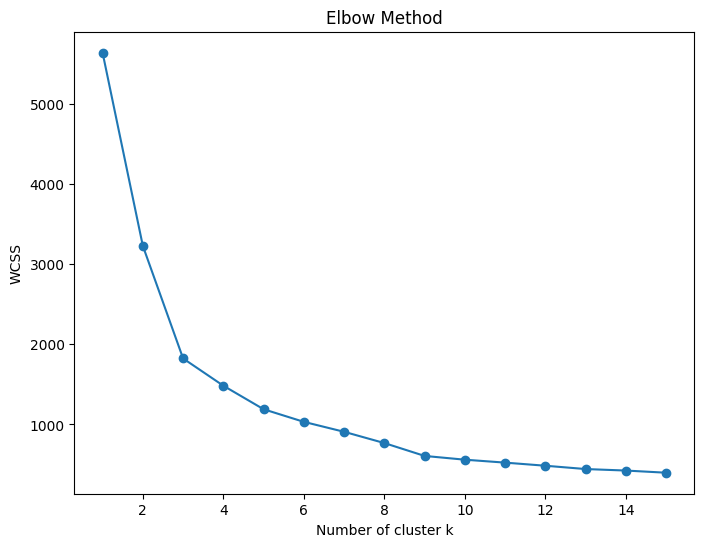

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 16):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 16), wcss, marker='o')
plt.xlabel("Number of cluster k")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)

segmentation_data['Cluster Segment'] = kmeans.fit_predict(scaled_data)

In [ ]:
segmentation_data['Cluster'] = cluster

In [ ]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster,Cluster Segment
185,15,85.90,1269.55,0.719908,1,0
2715,18,56.80,1074.65,0.338514,0,2
3825,2,20.00,40.90,0.223398,0,2
1807,6,84.20,519.15,0.825679,1,0
132,40,104.80,4131.95,0.460855,2,1
...,...,...,...,...,...,...
6366,66,104.90,6891.45,0.149501,2,1
315,19,86.00,1532.45,0.682206,1,0
2439,2,90.35,190.50,0.692050,1,0
5002,68,110.20,7467.50,0.069569,2,1


In [ ]:
cluster_summary = segmentation_data.groupby('Cluster').mean(numeric_only=True)

In [ ]:
cluster_name = {
    0:'Budget Loyal Customers',
    1:'High Risk new Customers',
    2:'Loyal Premium Customers'
}

In [ ]:
segmentation_data['Cluster Segment'] = segmentation_data['Cluster'].map(cluster_name)

In [ ]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster,Cluster Segment
185,15,85.90,1269.55,0.719908,1,High Risk new Customers
2715,18,56.80,1074.65,0.338514,0,Budget Loyal Customers
3825,2,20.00,40.90,0.223398,0,Budget Loyal Customers
1807,6,84.20,519.15,0.825679,1,High Risk new Customers
132,40,104.80,4131.95,0.460855,2,Loyal Premium Customers
...,...,...,...,...,...,...
6366,66,104.90,6891.45,0.149501,2,Loyal Premium Customers
315,19,86.00,1532.45,0.682206,1,High Risk new Customers
2439,2,90.35,190.50,0.692050,1,High Risk new Customers
5002,68,110.20,7467.50,0.069569,2,Loyal Premium Customers


In [ ]:
print('Segmented Data Preview:')
print(segmentation_data.head())

Segmented Data Preview:
      Tenure Months  Monthly Charges  Total Charges  Churn Probability  \
185              15             85.9        1269.55           0.719908   
2715             18             56.8        1074.65           0.338514   
3825              2             20.0          40.90           0.223398   
1807              6             84.2         519.15           0.825679   
132              40            104.8        4131.95           0.460855   

      Cluster          Cluster Segment  
185         1  High Risk new Customers  
2715        0   Budget Loyal Customers  
3825        0   Budget Loyal Customers  
1807        1  High Risk new Customers  
132         2  Loyal Premium Customers  


In [ ]:
print('\nCluster Summary (Mean Values):')
print(cluster_summary)


Cluster Summary (Mean Values):
         Tenure Months  Monthly Charges  Total Charges  Churn Probability
Cluster                                                                  
0            32.272109        33.338776    1087.772562           0.131200
1            11.112132        73.517739     901.659283           0.683330
2            58.912736        90.652476    5342.704835           0.230556


In [ ]:
print('\nCluster Summary (Mean Values):')
print(cluster_summary)


Cluster Summary (Mean Values):
         Tenure Months  Monthly Charges  Total Charges  Churn Probability
Cluster                                                                  
0            32.272109        33.338776    1087.772562           0.131200
1            11.112132        73.517739     901.659283           0.683330
2            58.912736        90.652476    5342.704835           0.230556


Would you like to visualize these clusters, for example, using a scatter plot of 'Tenure Months' vs 'Monthly Charges' colored by cluster?

Would you like to visualize these clusters, for example, using a scatter plot of 'Tenure Months' vs 'Monthly Charges' colored by cluster?

In [ ]:
plt.figure(figsize = (10,8))


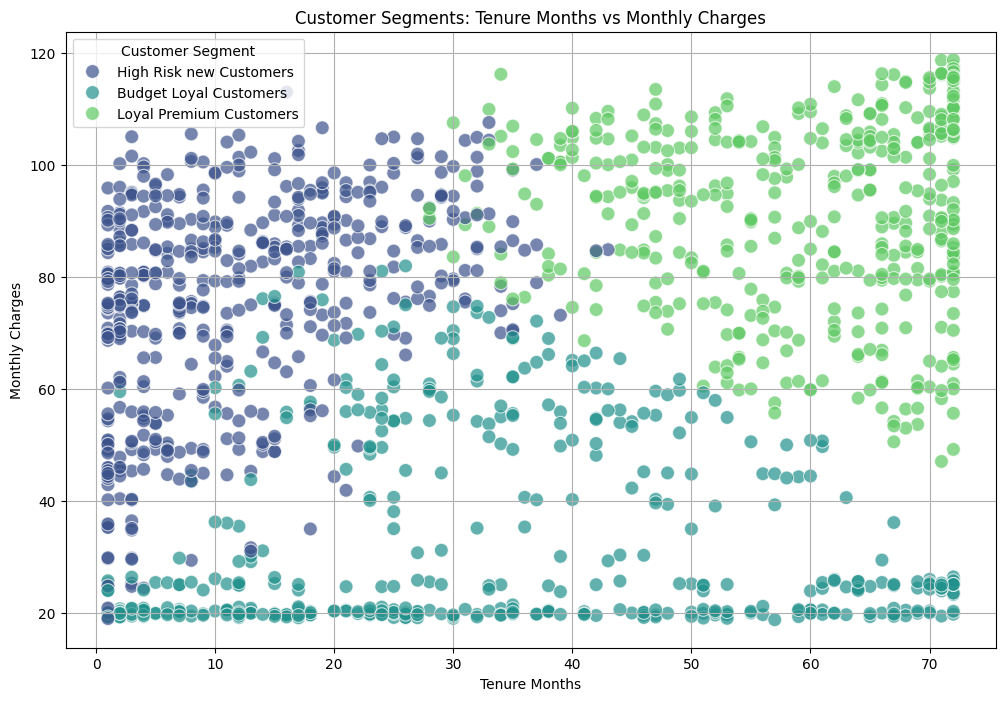

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Tenure Months',
    y='Monthly Charges',
    hue='Cluster Segment',
    data=segmentation_data,
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.title('Customer Segments: Tenure Months vs Monthly Charges')
plt.xlabel('Tenure Months')
plt.ylabel('Monthly Charges')
plt.grid(True)
plt.legend(title='Customer Segment')
plt.show()

This plot helps to visually differentiate the customer segments based on their tenure and monthly charges. Would you like to explore other visualizations or analyze specific characteristics of these clusters further?

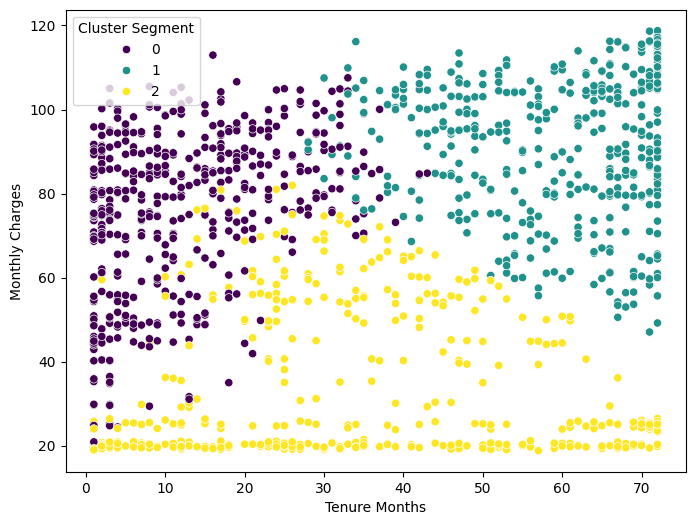

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='Tenure Months',
    y='Monthly Charges',
    hue='Cluster Segment',
    data=segmentation_data,
    palette='viridis'
)

plt.show()

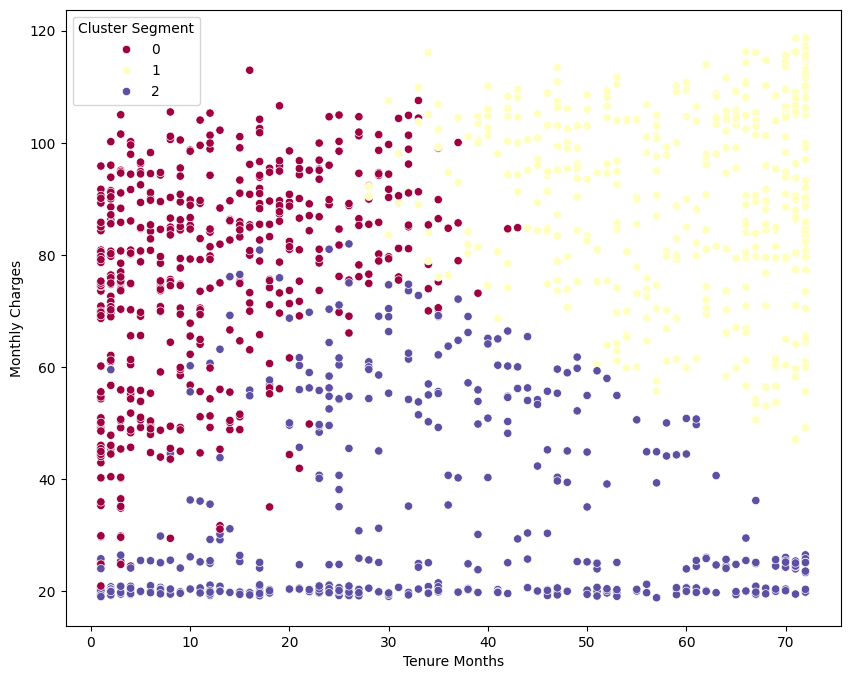

In [ ]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x='Tenure Months',
    y='Monthly Charges',
    hue='Cluster Segment',
    data=segmentation_data,
    palette='Spectral'
)

plt.show()

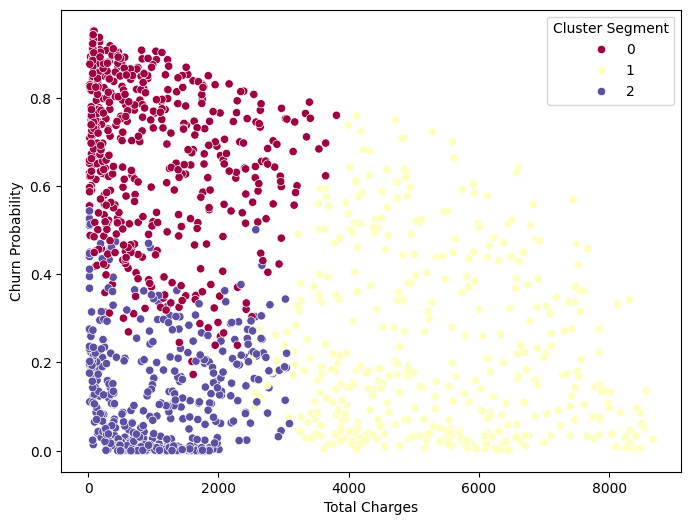

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='Total Charges',
    y='Churn Probability',
    hue='Cluster Segment',
    data=segmentation_data,
    palette='Spectral'
)

plt.show()